In [ ]:
# ==========================================
# 1. LOAD THE DATASET
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Read the uploaded CSV file
df = pd.read_csv("diabetes.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Display dataset shape
print("\nDataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

Saving diabetes.csv to diabetes (1).csv
First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Dataset shape: (768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [ ]:
# ==========================================
# 2. SEPARATE FEATURES AND TARGET
# ==========================================

# Input features
X = df.drop("Outcome", axis=1)

# Target variable
y = df["Outcome"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget variable:")
print("Outcome")

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Input features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target variable:
Outcome

Shape of X: (768, 8)
Shape of y: (768,)


In [ ]:
# ==========================================
# 3. IDENTIFY AND HANDLE INVALID VALUES
# ==========================================

# Check missing values
print("Missing values before processing:")
print(df.isnull().sum())

# Columns where zero is considered an invalid/missing measurement
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Count zeros before replacement
print("\nNumber of zero values before handling:")

for column in invalid_columns:
    print(column, ":", (df[column] == 0).sum())

# Replace zero values with NaN
df[invalid_columns] = df[invalid_columns].replace(0, np.nan)

# Check missing values after replacing zeros
print("\nMissing values after replacing invalid zeros:")
print(df.isnull().sum())

# Fill missing values with median
for column in invalid_columns:
    df[column] = df[column].fillna(df[column].median())

# Check again
print("\nMissing values after median imputation:")
print(df.isnull().sum())

Missing values before processing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Number of zero values before handling:
Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0

Missing values after replacing invalid zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction

In [ ]:
# ==========================================
# 4. TRAIN-TEST SPLIT USING STRATIFICATION
# ==========================================

from sklearn.model_selection import train_test_split

# Separate X and y again after preprocessing
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training data shape: (614, 8)
Testing data shape: (154, 8)

Training target distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing target distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [ ]:
# ==========================================
# 5. FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Original training data:")
display(X_train.head())

print("\nScaled training data:")
print(X_train_scaled[:5])

Original training data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90,62.0,12,43.0,27.2,0.580,24
711,5,126,78.0,27,22.0,29.6,0.439,40
373,2,105,58.0,40,94.0,34.9,0.225,25
46,1,146,56.0,27,102.5,29.7,0.564,29
682,0,95,64.0,39,105.0,44.6,0.366,22



Scaled training data:
[[-0.85135507 -1.0568694  -0.82668697 -1.8952899  -1.17037761 -0.76615019
   0.31079384 -0.79216928]
 [ 0.35657564  0.1428554   0.4770088  -0.22473578 -1.42764161 -0.41444809
  -0.11643851  0.56103382]
 [-0.5493724  -0.55698407 -1.15261091  1.22307779 -0.54559361  0.36222739
  -0.76486207 -0.70759409]
 [-0.85135507  0.80936917 -1.31557289 -0.22473578 -0.44146295 -0.39979383
   0.26231357 -0.36929331]
 [-1.15333775 -0.89024096 -0.663725    1.11170751 -0.41083628  1.78369005
  -0.33762972 -0.96131967]]


In [ ]:
# ==========================================
# 6. BUILD CLASSIFICATION MODELS
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

# K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

# Decision Tree
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

print("Three classification models created:")
print("1. Logistic Regression")
print("2. K-Nearest Neighbors")
print("3. Decision Tree")

Three classification models created:
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree


In [ ]:
# ==========================================
# 7. TRAIN THE MODELS
# ==========================================

# Train Logistic Regression
logistic_model.fit(X_train_scaled, y_train)

# Train KNN
knn_model.fit(X_train_scaled, y_train)

# Train Decision Tree
decision_tree_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


In [ ]:
# ==========================================
# 8. GENERATE PREDICTIONS
# ==========================================

# Logistic Regression predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

# KNN predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Decision Tree predictions
y_pred_tree = decision_tree_model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 20 actual values:")
print(y_test.values[:20])

print("\nFirst 20 Logistic Regression predictions:")
print(y_pred_logistic[:20])

print("\nFirst 20 KNN predictions:")
print(y_pred_knn[:20])

print("\nFirst 20 Decision Tree predictions:")
print(y_pred_tree[:20])

Predictions generated successfully!

First 20 actual values:
[0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0]

First 20 Logistic Regression predictions:
[0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 1 0]

First 20 KNN predictions:
[0 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0]

First 20 Decision Tree predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 1 0 0 1 0 0 1 0]


In [ ]:
# ==========================================
# 9. CONFUSION MATRICES
# ==========================================

from sklearn.metrics import confusion_matrix

# Calculate confusion matrices
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

print("\nKNN Confusion Matrix:")
print(cm_knn)

print("\nDecision Tree Confusion Matrix:")
print(cm_tree)

Logistic Regression Confusion Matrix:
[[79 21]
 [24 30]]

KNN Confusion Matrix:
[[86 14]
 [15 39]]

Decision Tree Confusion Matrix:
[[87 13]
 [14 40]]


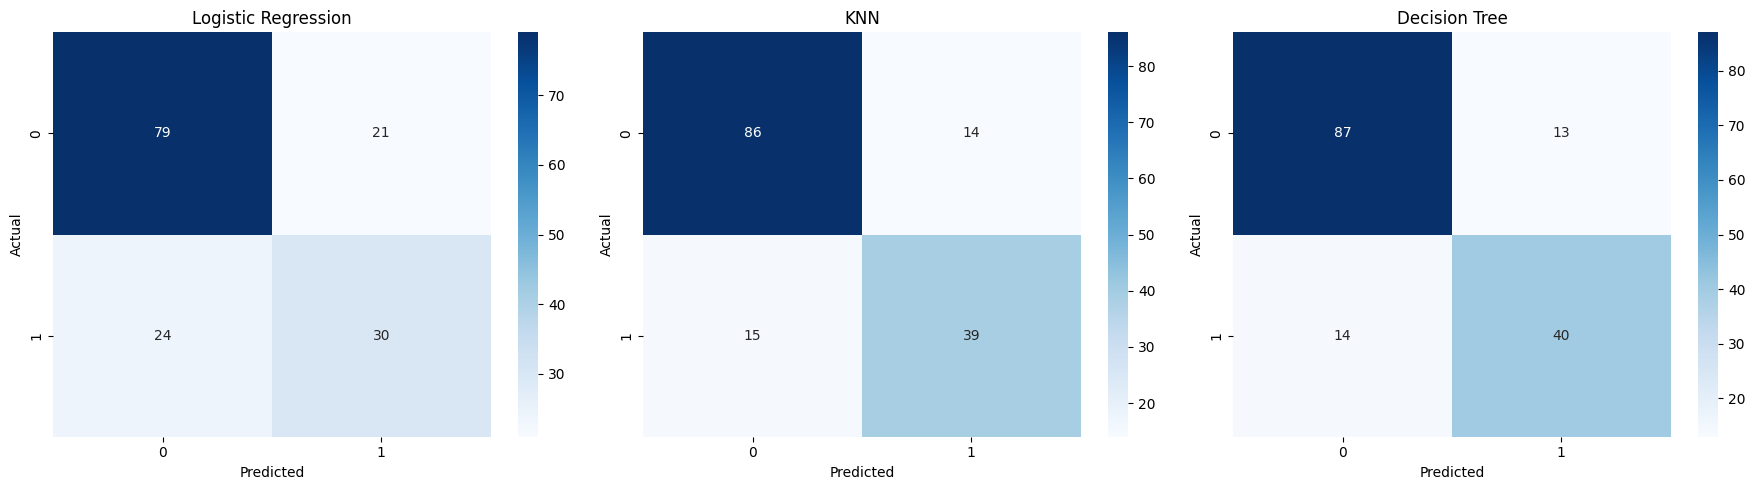

In [ ]:
# ==========================================
# VISUALIZE CONFUSION MATRICES
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("KNN")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[2]
)
axes[2].set_title("Decision Tree")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 10. CLASSIFICATION PERFORMANCE METRICS
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Function to calculate metrics
def calculate_metrics(model_name, y_true, y_pred, y_probability):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_probability)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }


# Probability predictions
logistic_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]
knn_probability = knn_model.predict_proba(X_test_scaled)[:, 1]
tree_probability = decision_tree_model.predict_proba(X_test)[:, 1]


# Calculate metrics
results = []

results.append(
    calculate_metrics(
        "Logistic Regression",
        y_test,
        y_pred_logistic,
        logistic_probability
    )
)

results.append(
    calculate_metrics(
        "KNN",
        y_test,
        y_pred_knn,
        knn_probability
    )
)

results.append(
    calculate_metrics(
        "Decision Tree",
        y_test,
        y_pred_tree,
        tree_probability
    )
)


# Convert results to DataFrame
results_df = pd.DataFrame(results)

print("Model Performance Comparison:")
display(results_df)

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.588235,0.555556,0.571429,0.826296
1,KNN,0.811688,0.735849,0.722222,0.728972,0.863148
2,Decision Tree,0.824675,0.754717,0.740741,0.747664,0.912130


In [ ]:
# ==========================================
# CLASSIFICATION REPORTS
# ==========================================

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(y_test, y_pred_logistic))


print("=" * 60)
print("K-NEAREST NEIGHBORS")
print("=" * 60)
print(classification_report(y_test, y_pred_knn))


print("=" * 60)
print("DECISION TREE")
print("=" * 60)
print(classification_report(y_test, y_pred_tree))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154

K-NEAREST NEIGHBORS
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       100
           1       0.74      0.72      0.73        54

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154

DECISION TREE
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       100
           1       0.75      0.74      0.75        54

    accuracy                           0.82       154
   macro avg       0.81      0.81      0.81       154
weighted avg       0

In [ ]:
# ==========================================
# 11. MODEL COMPARISON AND INTERPRETATION
# ==========================================

# Sort models by F1-score
comparison = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

print("Models ranked according to F1-Score:")
display(comparison)

# Best model
best_model = comparison.iloc[0]

print("\nBest performing model based on F1-Score:")
print(best_model["Model"])

print("\nPerformance:")
print("Accuracy :", round(best_model["Accuracy"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall   :", round(best_model["Recall"], 4))
print("F1-Score :", round(best_model["F1-Score"], 4))
print("ROC-AUC  :", round(best_model["ROC-AUC"], 4))

Models ranked according to F1-Score:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Decision Tree,0.824675,0.754717,0.740741,0.747664,0.912130
1,KNN,0.811688,0.735849,0.722222,0.728972,0.863148
0,Logistic Regression,0.707792,0.588235,0.555556,0.571429,0.826296



Best performing model based on F1-Score:
Decision Tree

Performance:
Accuracy : 0.8247
Precision: 0.7547
Recall   : 0.7407
F1-Score : 0.7477
ROC-AUC  : 0.9121
